In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

In [2]:
def adaptive_point_style(n: int) -> dict:
    """
    Адаптивный внешний вид scatter-точек.

    n <= 10:
        точки очень крупные и почти непрозрачные.

    n <= 100:
        точки заметные, но уже с умеренной прозрачностью.

    n <= 1000:
        точки уменьшаются и становятся прозрачнее.

    n > 1000:
        точки небольшие и прозрачные, чтобы не образовывалось
        сплошное нечитаемое пятно.
    """

    if n <= 10:
        return {
            "size": 105,
            "alpha": 0.92,
            "outline_width": 0.75,
            "jitter_fraction": 1.00
        }

    if n <= 100:
        return {
            "size": 58,
            "alpha": 0.68,
            "outline_width": 0.50,
            "jitter_fraction": 0.92
        }

    if n <= 1000:
        return {
            "size": 27,
            "alpha": 0.34,
            "outline_width": 0.28,
            "jitter_fraction": 0.78
        }

    return {
        "size": 12,
        "alpha": 0.12,
        "outline_width": 0.12,
        "jitter_fraction": 0.62
    }

In [3]:
def create_demo_dataset(
    random_state: int = 42
) -> pd.DataFrame:
    """
    Создаёт синтетические данные для проверки raincloud plot.

    Для каждого сценария создаётся:
    - class_0;
    - class_1.

    Число объектов в каждом классе:
    10, 100, 1000, 10000.

    Признаки:
    - age;
    - glucose;
    - bmi.

    Распределения class_0 и class_1 частично пересекаются,
    чтобы на KDE было видно перекрытие.
    """

    rng = np.random.default_rng(random_state)

    scenarios = {
        "n=10": 10,
        "n=100": 100,
        "n=1000": 1000,
        "n=10000": 10000
    }

    rows = []

    for scenario_name, n_per_class in scenarios.items():

        # -------------------- class_0 -------------------------
        age_0 = np.clip(
            rng.normal(
                loc=38,
                scale=11,
                size=n_per_class
            ),
            0,
            85
        )

        glucose_0 = np.clip(
            rng.normal(
                loc=112,
                scale=24,
                size=n_per_class
            ),
            40,
            280
        )

        bmi_0 = np.clip(
            rng.gamma(
                shape=10,
                scale=2.55,
                size=n_per_class
            ) + 8,
            14,
            65
        )

        # -------------------- class_1 -------------------------
        age_1 = np.clip(
            rng.normal(
                loc=31,
                scale=10,
                size=n_per_class
            ),
            0,
            85
        )

        glucose_1 = np.clip(
            rng.normal(
                loc=128,
                scale=29,
                size=n_per_class
            ),
            40,
            280
        )

        bmi_1 = np.clip(
            rng.gamma(
                shape=9,
                scale=2.95,
                size=n_per_class
            ) + 9,
            14,
            65
        )

        # Добавляем class_0.
        for age, glucose, bmi in zip(
            age_0,
            glucose_0,
            bmi_0
        ):
            rows.append({
                "scenario": scenario_name,
                "n_per_class": n_per_class,
                "class": "class_0",
                "age": age,
                "glucose": glucose,
                "bmi": bmi
            })

        # Добавляем class_1.
        for age, glucose, bmi in zip(
            age_1,
            glucose_1,
            bmi_1
        ):
            rows.append({
                "scenario": scenario_name,
                "n_per_class": n_per_class,
                "class": "class_1",
                "age": age,
                "glucose": glucose,
                "bmi": bmi
            })

    return pd.DataFrame(rows)


demo_df = create_demo_dataset(random_state=42)

print(demo_df.head())

print(
    demo_df.groupby(["scenario", "class"])
    .size()
)

  scenario  n_per_class    class        age     glucose        bmi
0     n=10           10  class_0  41.351888  133.105551  31.213217
1     n=10           10  class_0  26.560175  130.667006  43.668561
2     n=10           10  class_0  46.254963  113.584737  29.407658
3     n=10           10  class_0  48.346212  139.053789  37.115724
4     n=10           10  class_0  16.538613  123.220224  36.069188
scenario  class  
n=10      class_0       10
          class_1       10
n=100     class_0      100
          class_1      100
n=1000    class_0     1000
          class_1     1000
n=10000   class_0    10000
          class_1    10000
dtype: int64


In [4]:
CLASS_COLORS = {
    "class_0": "#2A9D8F",
    "class_1": "#E76F51"
}

SCENARIOS = [
    "n=10",
    "n=100",
    "n=1000",
    "n=10000"
]

In [5]:
def raincloud_horizontal(
    dataset: pd.DataFrame,
    feature_name: str,
    class_column: str = "class",
    class_order: list | None = None,
    class_colors: dict | None = None,

    # KDE сверху
    kde_baseline: float = 2.20,
    kde_height: float = 0.62,
    kde_alpha: float = 0.32,
    kde_line_width: float = 2.0,
    kde_bandwidth: float = 0.85,

    # Scatter: ближе к KDE
    points_start_y: float = 1.58,
    points_gap_y: float = 0.27,
    points_jitter_height: float = 0.115,

    # Boxplot: ближе к scatter
    boxes_start_y: float = 0.88,
    boxes_gap_y: float = 0.27,
    box_width: float = 0.22,
    box_line_width: float = 1.8,
    median_line_width: float = 2.5,
    boxplot_whiskers=(0, 100),

    # Масштаб данных
    x_limits: tuple | None = None,
    x_ticks=None,

    # Оформление
    axis=None,
    
    x_label: str | None = None,
    random_state: int = 123,
    show_legend: bool = True
):
    """
    Горизонтальный raincloud plot на одной оси.

    Сверху: наложенные KDE.
    По центру: отдельные строки scatter для классов.
    Снизу: отдельные горизонтальные boxplot для классов.
    """

    required_columns = [feature_name, class_column]

    missing_columns = [
        column
        for column in required_columns
        if column not in dataset.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Отсутствуют столбцы: {missing_columns}\n"
            f"Есть столбцы: {dataset.columns.tolist()}"
        )

    plot_data = dataset[
        [feature_name, class_column]
    ].copy()

    plot_data[feature_name] = pd.to_numeric(
        plot_data[feature_name],
        errors="coerce"
    )

    plot_data = plot_data.dropna(
        subset=[feature_name, class_column]
    )

    if plot_data.empty:
        raise ValueError(
            f"Нет числовых значений для '{feature_name}'."
        )

    available_classes = list(
        plot_data[class_column].unique()
    )

    if class_order is None:
        class_names = available_classes
    else:
        class_names = [
            name
            for name in class_order
            if name in available_classes
        ]

    if class_colors is None:
        class_colors = {
            "class_0": "#2A9D8F",
            "class_1": "#E76F51"
        }

    all_values = plot_data[
        feature_name
    ].to_numpy(dtype=float)

    if x_limits is None:
        x_min = float(np.min(all_values))
        x_max = float(np.max(all_values))
        x_range = x_max - x_min

        if x_range == 0:
            x_range = 1.0

        x_limits = (
            x_min - 0.06 * x_range,
            x_max + 0.06 * x_range
        )

    if axis is None:
        figure, axis = plt.subplots(
            figsize=(13, 4.8)
        )
    else:
        figure = axis.figure

    rng = np.random.default_rng(random_state)

    n_classes = len(class_names)

    points_y = [
        points_start_y - i * points_gap_y
        for i in range(n_classes)
    ]

    boxes_y = [
        boxes_start_y - i * boxes_gap_y
        for i in range(n_classes)
    ]

    x_grid = np.linspace(
        x_limits[0],
        x_limits[1],
        600
    )

    legend_handles = []

    # =========================================================
    # KDE: верхняя часть
    # =========================================================
    for class_name in class_names:
        values = plot_data.loc[
            plot_data[class_column] == class_name,
            feature_name
        ].to_numpy(dtype=float)

        color = class_colors.get(
            class_name,
            "#457B9D"
        )

        if len(values) >= 2 and np.std(values) > 0:
            kde = gaussian_kde(
                values,
                bw_method=kde_bandwidth
            )

            density = kde(x_grid)

            if density.max() > 0:
                density = (
                    density / density.max()
                    * kde_height
                )

            axis.fill_between(
                x_grid,
                kde_baseline,
                kde_baseline + density,
                color=color,
                alpha=kde_alpha,
                zorder=1
            )

            axis.plot(
                x_grid,
                kde_baseline + density,
                color=color,
                linewidth=kde_line_width,
                zorder=2
            )

        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor=color,
                alpha=kde_alpha,
                label=str(class_name)
            )
        )

    # =========================================================
    # Scatter: отдельная строка на каждый класс
    # =========================================================
    for class_index, class_name in enumerate(class_names):
        values = plot_data.loc[
            plot_data[class_column] == class_name,
            feature_name
        ].to_numpy(dtype=float)

        color = class_colors.get(
            class_name,
            "#457B9D"
        )

        style = adaptive_point_style(len(values))

        current_jitter = (
            points_jitter_height
            * style["jitter_fraction"]
        )

        y_jitter = rng.uniform(
            low=-current_jitter,
            high=current_jitter,
            size=len(values)
        )

        axis.scatter(
            values,
            np.full(len(values), points_y[class_index])
            + y_jitter,
            s=style["size"],
            alpha=style["alpha"],
            color=color,
            edgecolors="#1F1F1F",
            linewidths=style["outline_width"],
            zorder=5
        )

    # =========================================================
    # Boxplot: отдельный на каждый класс
    # =========================================================
    for class_index, class_name in enumerate(class_names):
        values = plot_data.loc[
            plot_data[class_column] == class_name,
            feature_name
        ].to_numpy(dtype=float)

        color = class_colors.get(
            class_name,
            "#457B9D"
        )

        result = axis.boxplot(
            [values],
            positions=[boxes_y[class_index]],
            widths=box_width,
            vert=False,
            whis=boxplot_whiskers,
            showfliers=False,
            patch_artist=True,
            manage_ticks=False
        )

        box_patch = result["boxes"][0]
        box_patch.set_facecolor("white")
        box_patch.set_edgecolor(color)
        box_patch.set_linewidth(box_line_width)

        result["medians"][0].set_color(color)
        result["medians"][0].set_linewidth(median_line_width)

        for line in result["whiskers"]:
            line.set_color(color)
            line.set_linewidth(box_line_width)

        for line in result["caps"]:
            line.set_color(color)
            line.set_linewidth(box_line_width)

    # =========================================================
    # Оформление
    # =========================================================
    axis.set_xlim(x_limits)

    axis.set_ylim(
        min(boxes_y) - 0.24,
        kde_baseline + kde_height + 0.17
    )

    

    axis.set_xlabel(
        x_label if x_label else feature_name,
        fontsize=11
    )

    # ЛЕВЫЕ ПОДПИСИ УБРАНЫ.
    axis.set_yticks([])

    axis.grid(
        axis="x",
        linestyle="--",
        alpha=0.22
    )

    axis.grid(axis="y", visible=False)

    axis.xaxis.set_major_locator(
        MaxNLocator(nbins=8)
    )

    axis.xaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    axis.tick_params(
        axis="x",
        which="major",
        length=6
    )

    axis.tick_params(
        axis="x",
        which="minor",
        length=3
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_visible(False)

    if x_ticks is not None:
        axis.set_xticks(x_ticks)

    if show_legend:
        axis.legend(
            handles=legend_handles,
            
            loc="upper right",
            frameon=True,
            fontsize=9
        )

    return figure, axis

In [ ]:
def raincloud_vertical(
    dataset: pd.DataFrame,
    feature_name: str,
    class_column: str = "class",
    class_order: list | None = None,
    class_colors: dict | None = None,

    # Компактное расположение зон:
    # boxplot -> scatter -> KDE
    box_center_x: float = 0.50,
    points_center_x: float = 1.23,
    density_start_x: float = 1.82,

    # Разведение классов внутри boxplot и scatter
    box_class_distance: float = 0.32,
    points_class_distance: float = 0.40,
    points_jitter_width: float = 0.115,

    # KDE
    density_width: float = 0.82,
    kde_alpha: float = 0.32,
    kde_line_width: float = 2.0,
    kde_bandwidth: float = 0.85,

    # Boxplot
    box_width: float = 0.25,
    box_line_width: float = 1.8,
    median_line_width: float = 2.5,
    boxplot_whiskers=(0, 100),

    # Шкала значений
    y_limits: tuple | None = None,
    y_ticks=None,

    # Оформление
    axis=None,
    
    y_label: str | None = None,
    random_state: int = 123,
    show_legend: bool = True
):
    """
    Вертикальный raincloud plot на одной оси.

    По оси Y идут значения признака.
    По оси X слева направо:
    отдельные boxplot -> отдельные scatter -> общие KDE.
    """

    required_columns = [feature_name, class_column]

    missing_columns = [
        column
        for column in required_columns
        if column not in dataset.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Отсутствуют столбцы: {missing_columns}\n"
            f"Есть столбцы: {dataset.columns.tolist()}"
        )

    plot_data = dataset[
        [feature_name, class_column]
    ].copy()

    plot_data[feature_name] = pd.to_numeric(
        plot_data[feature_name],
        errors="coerce"
    )

    plot_data = plot_data.dropna(
        subset=[feature_name, class_column]
    )

    if plot_data.empty:
        raise ValueError(
            f"Нет числовых значений для '{feature_name}'."
        )

    available_classes = list(
        plot_data[class_column].unique()
    )

    if class_order is None:
        class_names = available_classes
    else:
        class_names = [
            name
            for name in class_order
            if name in available_classes
        ]

    if class_colors is None:
        class_colors = {
            "class_0": "#2A9D8F",
            "class_1": "#E76F51"
        }

    all_values = plot_data[
        feature_name
    ].to_numpy(dtype=float)

    if y_limits is None:
        y_min = float(np.min(all_values))
        y_max = float(np.max(all_values))
        y_range = y_max - y_min

        if y_range == 0:
            y_range = 1.0

        y_limits = (
            y_min - 0.06 * y_range,
            y_max + 0.06 * y_range
        )

    if axis is None:
        figure, axis = plt.subplots(
            figsize=(8, 6)
        )
    else:
        figure = axis.figure

    rng = np.random.default_rng(random_state)

    n_classes = len(class_names)

    class_offsets = np.linspace(
        -(n_classes - 1) / 2,
        +(n_classes - 1) / 2,
        n_classes
    )

    box_positions = (
        box_center_x
        + class_offsets * box_class_distance
    )

    scatter_positions = (
        points_center_x
        + class_offsets * points_class_distance
    )

    y_grid = np.linspace(
        y_limits[0],
        y_limits[1],
        600
    )

    legend_handles = []

    # =========================================================
    # KDE справа
    # =========================================================
    for class_name in class_names:
        values = plot_data.loc[
            plot_data[class_column] == class_name,
            feature_name
        ].to_numpy(dtype=float)

        color = class_colors.get(
            class_name,
            "#457B9D"
        )

        if len(values) >= 2 and np.std(values) > 0:
            kde = gaussian_kde(
                values,
                bw_method=kde_bandwidth
            )

            density = kde(y_grid)

            if density.max() > 0:
                density = (
                    density / density.max()
                    * density_width
                )

            axis.fill_betweenx(
                y_grid,
                density_start_x,
                density_start_x + density,
                color=color,
                alpha=kde_alpha,
                zorder=1
            )

            axis.plot(
                density_start_x + density,
                y_grid,
                color=color,
                linewidth=kde_line_width,
                zorder=2
            )

        legend_handles.append(
            Patch(
                facecolor=color,
                edgecolor=color,
                alpha=kde_alpha,
                label=str(class_name)
            )
        )

    # =========================================================
    # Scatter по центру
    # =========================================================
    for class_index, class_name in enumerate(class_names):
        values = plot_data.loc[
            plot_data[class_column] == class_name,
            feature_name
        ].to_numpy(dtype=float)

        color = class_colors.get(
            class_name,
            "#457B9D"
        )

        style = adaptive_point_style(len(values))

        current_jitter = (
            points_jitter_width
            * style["jitter_fraction"]
        )

        x_jitter = rng.uniform(
            low=-current_jitter,
            high=current_jitter,
            size=len(values)
        )

        axis.scatter(
            scatter_positions[class_index] + x_jitter,
            values,
            s=style["size"],
            alpha=style["alpha"],
            color=color,
            edgecolors="#1F1F1F",
            linewidths=style["outline_width"],
            zorder=5
        )

    # =========================================================
    # Boxplot слева
    # =========================================================
    for class_index, class_name in enumerate(class_names):
        values = plot_data.loc[
            plot_data[class_column] == class_name,
            feature_name
        ].to_numpy(dtype=float)

        color = class_colors.get(
            class_name,
            "#457B9D"
        )

        result = axis.boxplot(
            [values],
            positions=[box_positions[class_index]],
            widths=box_width,
            vert=True,
            whis=boxplot_whiskers,
            showfliers=False,
            patch_artist=True,
            manage_ticks=False
        )

        box_patch = result["boxes"][0]
        box_patch.set_facecolor("white")
        box_patch.set_edgecolor(color)
        box_patch.set_linewidth(box_line_width)

        result["medians"][0].set_color(color)
        result["medians"][0].set_linewidth(median_line_width)

        for line in result["whiskers"]:
            line.set_color(color)
            line.set_linewidth(box_line_width)

        for line in result["caps"]:
            line.set_color(color)
            line.set_linewidth(box_line_width)

    # =========================================================
    # Оформление
    # =========================================================
    axis.set_xlim(
        min(box_positions) - 0.18,
        density_start_x + density_width + 0.20
    )

    axis.set_ylim(y_limits)

    axis.set_xticks([
        float(np.mean(box_positions)),
        float(np.mean(scatter_positions)),
        density_start_x + density_width / 2
    ])

    axis.set_xticklabels([
        "Boxplot",
        "Точки",
        "KDE"
    ])

    # ЛЕВАЯ ПОДПИСЬ ОСИ УБРАНА.
    axis.set_ylabel("")

    if y_ticks is not None:
        axis.set_yticks(y_ticks)

    

    axis.grid(
        axis="y",
        linestyle="--",
        alpha=0.22
    )

    axis.grid(axis="x", visible=False)

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    if show_legend:
        axis.legend(
            handles=legend_handles,
            title="Класс",
            loc="upper right",
            frameon=True,
            fontsize=9
        )

    return figure, axis

/tmp/ipykernel_35624/25703926.py:259: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  result = axis.boxplot(
/tmp/ipykernel_35624/25703926.py:259: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  result = axis.boxplot(
/tmp/ipykernel_35624/25703926.py:259: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  result = axis.boxplot(
/tmp/ipykernel_35624/25703926.py:259: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  result = axis.boxplot(
/tmp/ipykernel_35624/25703926.py:259: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and wil

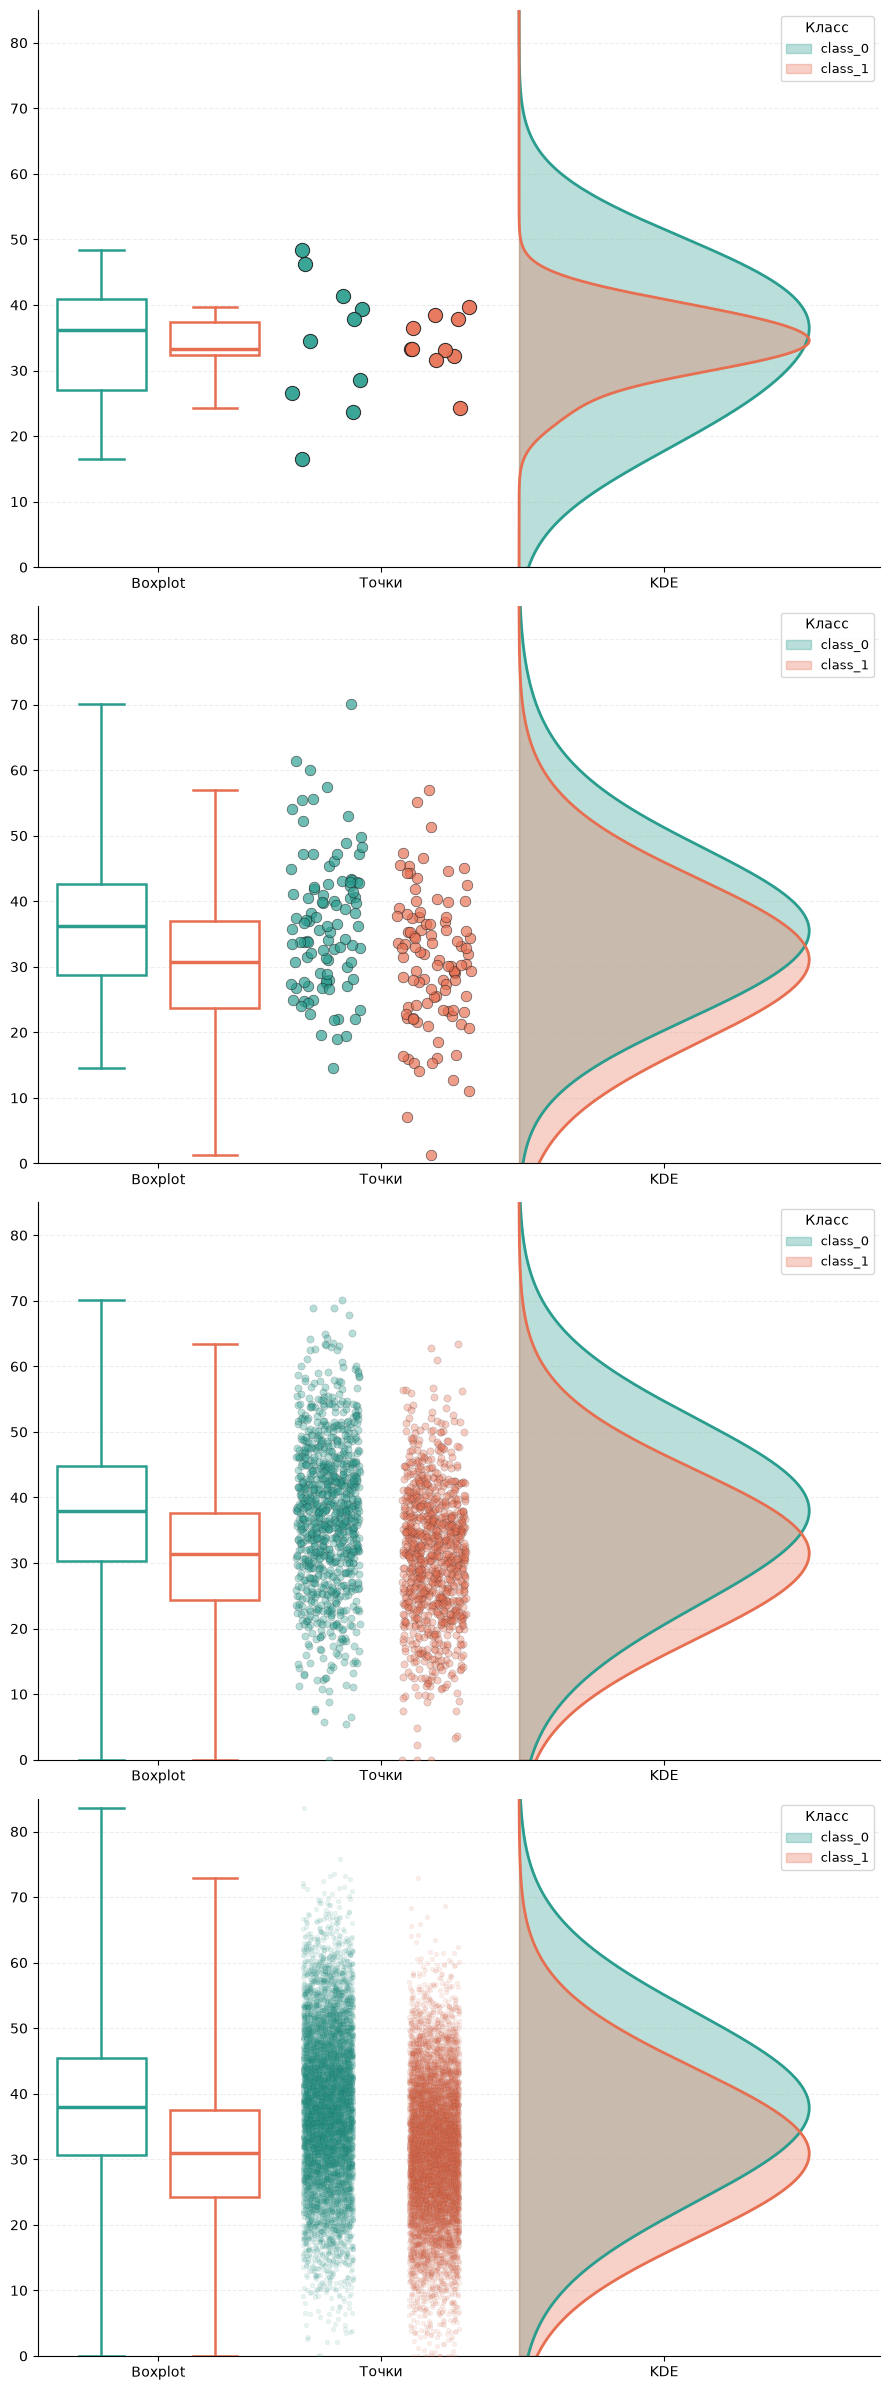

In [18]:
figure, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(9, 24)
)

for axis, scenario_name in zip(axes, SCENARIOS):

    scenario_data = demo_df.loc[
        demo_df["scenario"] == scenario_name
    ].copy()

    n_per_class = int(
        scenario_data["n_per_class"].iloc[0]
    )

    style = adaptive_point_style(n_per_class)

    raincloud_vertical(
        dataset=scenario_data,
        feature_name="age",
       
        class_column="class",
        class_order=["class_0", "class_1"],
        class_colors=CLASS_COLORS,

        # Compact: boxplot -> scatter -> KDE.
        box_center_x=0.80,
        box_class_distance=0.32,

        points_center_x=1.43,
        points_class_distance=0.30,
        points_jitter_width=0.115,

        density_start_x=1.82,
        density_width=0.82,

        kde_alpha=0.32,
        kde_line_width=2.0,
        kde_bandwidth=0.85,

        box_width=0.25,
        box_line_width=1.8,
        median_line_width=2.5,
        boxplot_whiskers=(0, 100),

        y_limits=(0, 85),
        y_ticks=np.arange(0, 86, 10),

        axis=axis,
        random_state=123,
        show_legend=True,

        

        y_label=""
    )

figure.tight_layout()
plt.show()

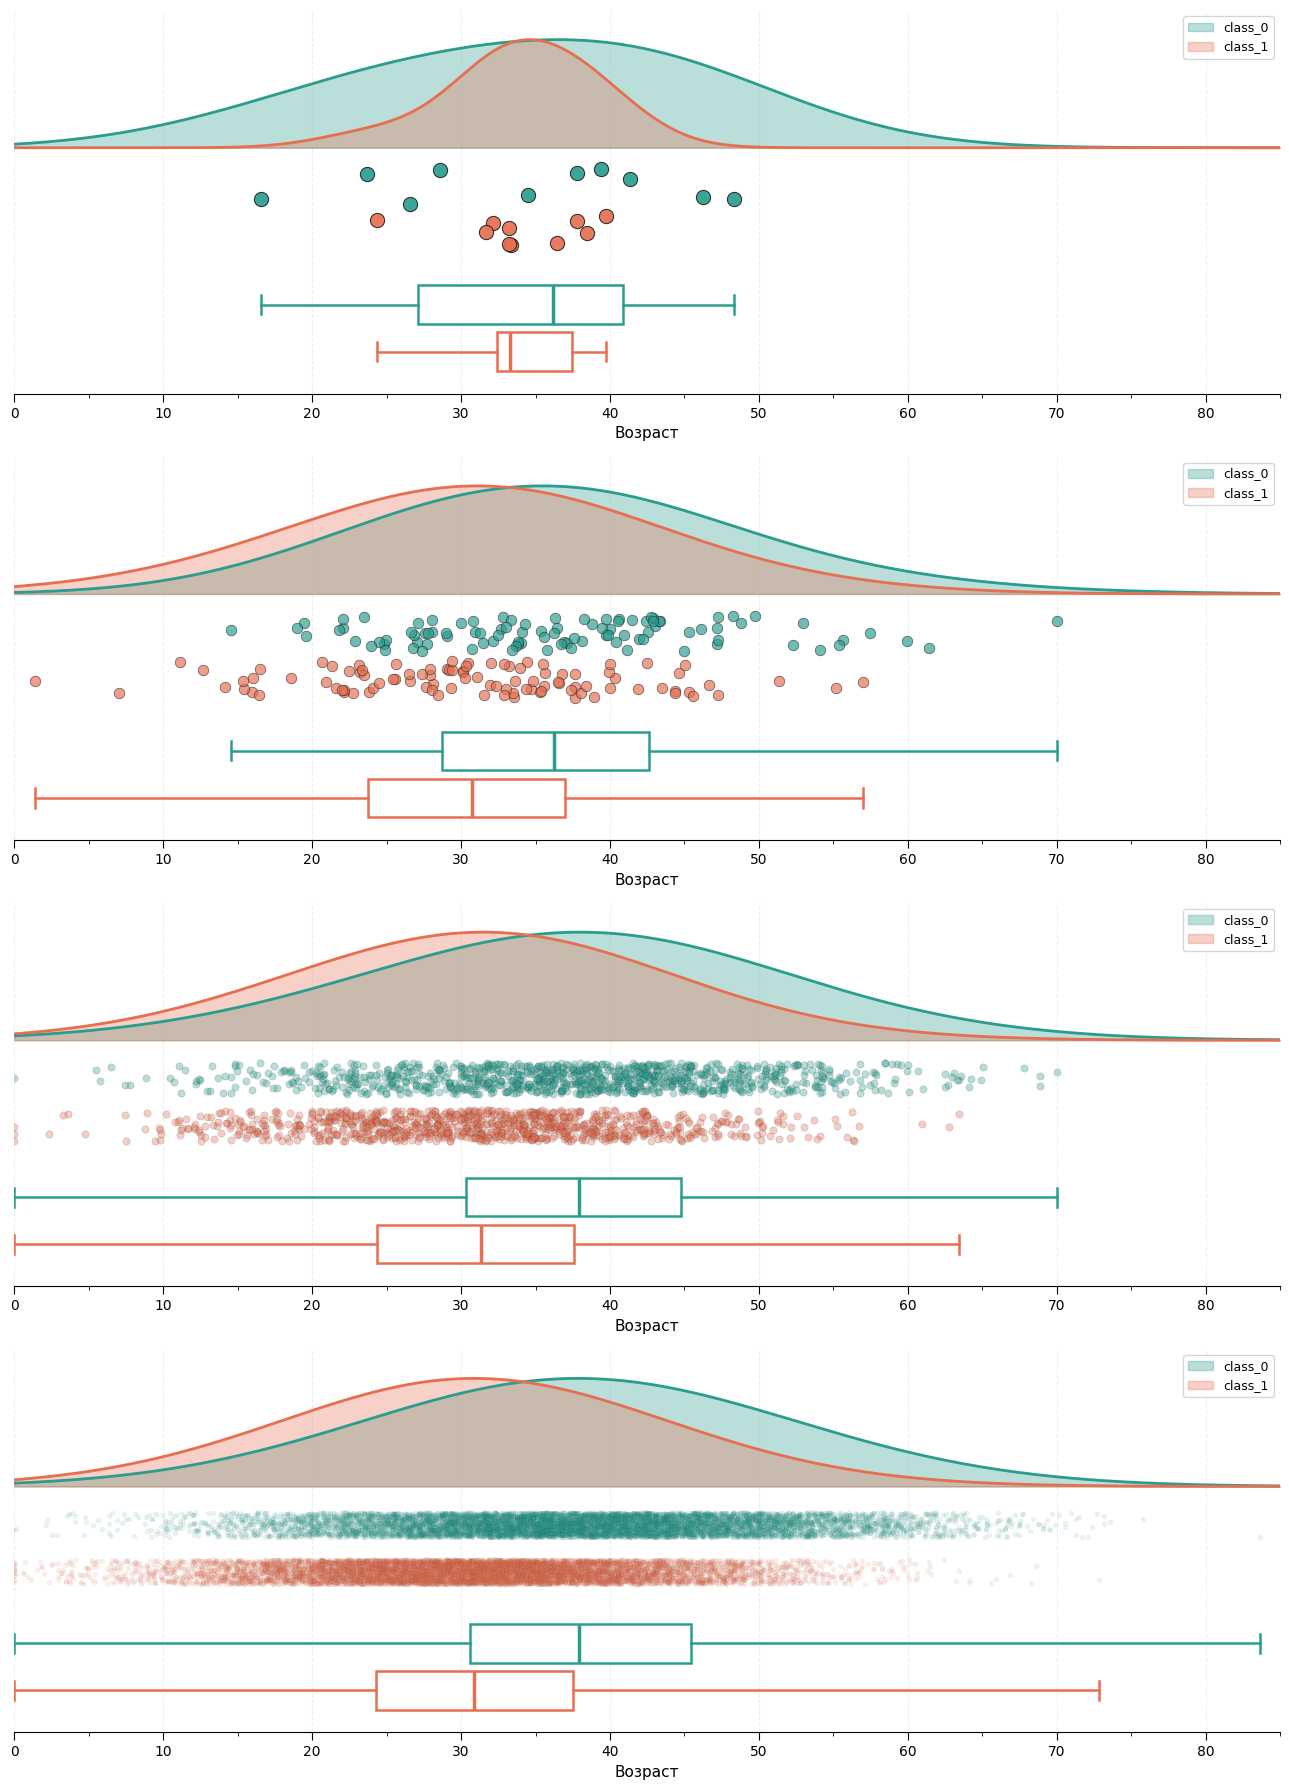

In [ ]:
figure, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(13, 18)
)

for axis, scenario_name in zip(axes, SCENARIOS):

    scenario_data = demo_df.loc[
        demo_df["scenario"] == scenario_name
    ].copy()

    n_per_class = int(
        scenario_data["n_per_class"].iloc[0]
    )

    style = adaptive_point_style(n_per_class)

    raincloud_horizontal(
        dataset=scenario_data,
        feature_name="age",
        class_column="class",
        class_order=["class_0", "class_1"],
        class_colors=CLASS_COLORS,

        # =====================================================
        # KDE: опускаем ближе к точкам
        # Было: kde_baseline=2.20
        # Теперь нижняя граница KDE = 1.94
        # =====================================================
        kde_baseline=1.94,
        kde_height=0.62,

        # =====================================================
        # Scatter: поднимаем ближе к KDE
        # Было: points_start_y=1.58, points_gap_y=0.27
        # class_0: y=1.72
        # class_1: y=1.45
        # =====================================================
        points_start_y=1.72,
        points_gap_y=0.27,
        points_jitter_height=0.115,

        # =====================================================
        # Boxplot: поднимаем ближе к scatter
        # class_0: y=1.04
        # class_1: y=0.77
        # =====================================================
        boxes_start_y=1.04,
        boxes_gap_y=0.27,
        box_width=0.22,

        # KDE
        kde_alpha=0.32,
        kde_line_width=2.0,
        kde_bandwidth=0.85,

        # Boxplot
        box_line_width=1.8,
        median_line_width=2.5,
        boxplot_whiskers=(0, 100),

        # Ось X
        x_limits=(0, 85),
        x_ticks=np.arange(0, 86, 10),

        axis=axis,
        random_state=123,
        show_legend=True,

        

        x_label="Возраст"
    )

figure.tight_layout()
plt.show()